In [2]:
!pip install yfinance 


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
target_asset = "AAPL"

market_indicators = ["^IXIC", "^GSPC", "^DJI"]

benchmark_assets = ["SPY", "QQQ"]

tickers = [target_asset] + market_indicators + benchmark_assets

start_date = "2018-01-01"
split_date = "2023-01-01"

tickers

['AAPL', '^IXIC', '^GSPC', '^DJI', 'SPY', 'QQQ']

In [3]:
prices = yf.download(tickers, start=start_date)["Close"]

prices = prices.ffill().dropna()

prices.head()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,QQQ,SPY,^DJI,^GSPC,^IXIC
2018-01-02,40.267078,150.222122,236.562210,24824.009766,2695.810059,7006.899902
2018-01-03,40.260067,151.681793,238.058487,24922.679688,2713.060059,7065.529785
2018-01-04,40.447067,151.947205,239.061783,25075.130859,2723.989990,7077.910156
2018-01-05,40.907566,153.473251,240.654968,25295.869141,2743.149902,7136.560059
2018-01-08,40.755627,154.070343,241.095062,25283.000000,2747.709961,7157.390137


In [4]:
prices.tail()

Ticker,AAPL,QQQ,SPY,^DJI,^GSPC,^IXIC
2026-06-08,301.540009,716.070007,739.219971,50786.011719,7405.729980,25929.660156
2026-06-09,290.549988,707.830017,737.049988,50872.109375,7386.649902,25678.820312
2026-06-10,291.579987,693.690002,725.429993,49918.781250,7266.990234,25169.500000
2026-06-11,295.630005,717.119995,737.760010,50848.750000,7394.299805,25809.660156
2026-06-12,291.130005,721.340027,741.750000,51202.261719,7431.459961,25888.843750


In [5]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2123 entries, 2018-01-02 to 2026-06-12
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2123 non-null   float64
 1   QQQ     2123 non-null   float64
 2   SPY     2123 non-null   float64
 3   ^DJI    2123 non-null   float64
 4   ^GSPC   2123 non-null   float64
 5   ^IXIC   2123 non-null   float64
dtypes: float64(6)
memory usage: 116.1 KB


In [6]:
prices.isna().sum()

Ticker
AAPL     0
QQQ      0
SPY      0
^DJI     0
^GSPC    0
^IXIC    0
dtype: int64

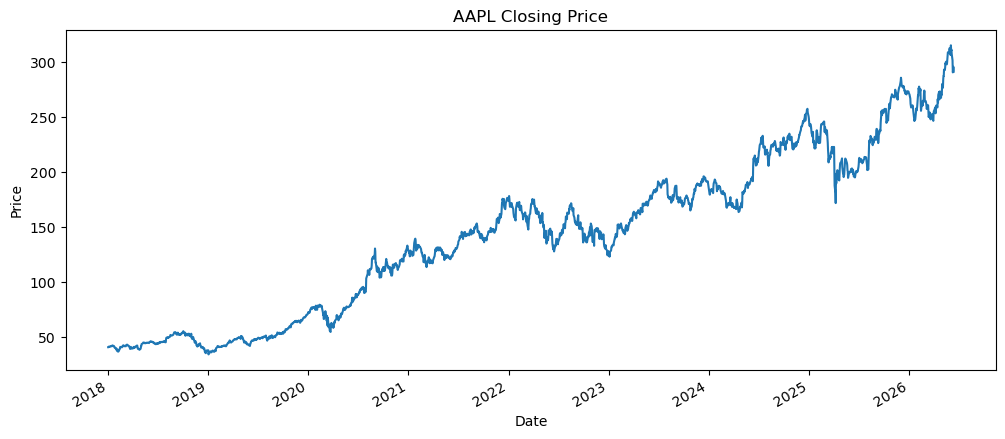

In [7]:
prices[target_asset].plot(figsize=(12, 5), title=f"{target_asset} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [8]:
df = prices.copy()

df.head()

Ticker,AAPL,QQQ,SPY,^DJI,^GSPC,^IXIC
2018-01-02,40.267078,150.222122,236.562210,24824.009766,2695.810059,7006.899902
2018-01-03,40.260067,151.681793,238.058487,24922.679688,2713.060059,7065.529785
2018-01-04,40.447067,151.947205,239.061783,25075.130859,2723.989990,7077.910156
2018-01-05,40.907566,153.473251,240.654968,25295.869141,2743.149902,7136.560059
2018-01-08,40.755627,154.070343,241.095062,25283.000000,2747.709961,7157.390137


In [9]:
df["ret_aapl"] = df[target_asset].pct_change()

df["ret_nasdaq"] = df["^IXIC"].pct_change()
df["ret_sp500"] = df["^GSPC"].pct_change()
df["ret_dowjones"] = df["^DJI"].pct_change()

df["ret_spy"] = df["SPY"].pct_change()
df["ret_qqq"] = df["QQQ"].pct_change()

df[["ret_aapl", "ret_nasdaq", "ret_sp500", "ret_dowjones", "ret_spy", "ret_qqq"]].tail()

Ticker,ret_aapl,ret_nasdaq,ret_sp500,ret_dowjones,ret_spy,ret_qqq
2026-06-08,-0.018872,0.008566,0.002978,-0.001588,0.002264,0.015616
2026-06-09,-0.036446,-0.009674,-0.002576,0.001695,-0.002936,-0.011507
2026-06-10,0.003545,-0.019834,-0.016199,-0.018740,-0.015766,-0.019977
2026-06-11,0.013890,0.025434,0.017519,0.018630,0.016997,0.033776
2026-06-12,-0.015222,0.003068,0.005026,0.006952,0.005408,0.005885


In [10]:
df["ma20"] = df[target_asset].rolling(20).mean()
df["ma50"] = df[target_asset].rolling(50).mean()

df["price_above_ma20"] = (df[target_asset] > df["ma20"]).map({
    False: 0,
    True: 1
})
df["price_above_ma50"] = (df[target_asset] > df["ma20"]).map({
    False: 0,
    True: 1
})
df["ma_gap"] = df["ma20"] / df["ma50"] - 1

df["momentum20"] = df[target_asset] / df[target_asset].shift(20) - 1

df["vol20"] = df["ret_aapl"].rolling(20).std() * (252 ** 0.5)

df[["ma20", "ma50", "price_above_ma20","price_above_ma50", "ma_gap", "momentum20", "vol20"]].tail()



#ma20              tendance courte
#ma50              tendance moyenne
#price_above_ma20/ma50   signal 0/1
#ma_gap            écart MA20 / MA50
#momentum20        performance sur 20 jours
#vol20             volatilité récente annualisée

Ticker,ma20,ma50,price_above_ma20,price_above_ma50,ma_gap,momentum20,vol20
2026-06-08,304.664500,282.062806,0,0,0.080130,0.028971,0.190568
2026-06-09,304.558000,282.902386,0,0,0.076548,-0.007278,0.233429
2026-06-10,304.397000,283.805926,0,0,0.072553,-0.010923,0.232218
2026-06-11,304.235001,284.647399,0,0,0.068814,-0.010841,0.232287
2026-06-12,303.881001,285.362105,0,0,0.064896,-0.023742,0.238119


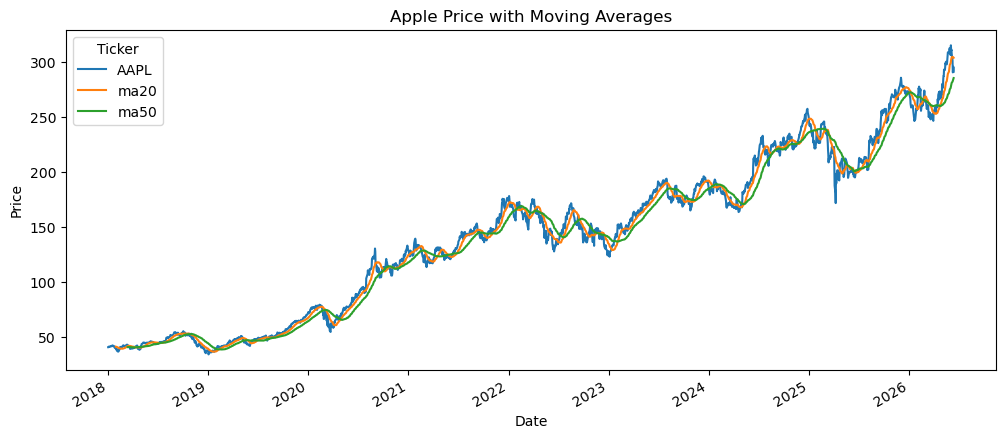

In [11]:
df[[target_asset, "ma20", "ma50"]].plot(
    figsize=(12, 5),
    title="Apple Price with Moving Averages"
)

plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [12]:
corr_same_day = df[
    ["ret_aapl", "ret_nasdaq", "ret_sp500", "ret_dowjones", "ret_spy", "ret_qqq"]
].corr()

corr_same_day

Ticker,ret_aapl,ret_nasdaq,ret_sp500,ret_dowjones,ret_spy,ret_qqq
Ticker,,,,,,
ret_aapl,1.000000,0.798503,0.765059,0.686694,0.766204,0.803714
ret_nasdaq,0.798503,1.000000,0.951151,0.828970,0.950776,0.991783
ret_sp500,0.765059,0.951151,1.000000,0.946536,0.998552,0.937108
ret_dowjones,0.686694,0.828970,0.946536,1.000000,0.944246,0.809127
ret_spy,0.766204,0.950776,0.998552,0.944246,1.000000,0.937382
ret_qqq,0.803714,0.991783,0.937108,0.809127,0.937382,1.000000


In [13]:
df["ret_aapl_next_day"] = df["ret_aapl"].shift(-1)

df[["ret_aapl", "ret_aapl_next_day"]].tail()

Ticker,ret_aapl,ret_aapl_next_day
2026-06-08,-0.018872,-0.036446
2026-06-09,-0.036446,0.003545
2026-06-10,0.003545,0.013890
2026-06-11,0.013890,-0.015222
2026-06-12,-0.015222,NaN


In [14]:
predictive_corr = df[
    [
        "ret_aapl",
        "ret_nasdaq",
        "ret_sp500",
        "ret_dowjones",
        "price_above_ma20",
        "ma_gap",
        "momentum20",
        "vol20",
        "ret_aapl_next_day"
    ]
].corr()

predictive_corr["ret_aapl_next_day"].sort_values(ascending=False)

Ticker
ret_aapl_next_day    1.000000
price_above_ma20     0.036795
ma_gap              -0.002135
momentum20          -0.002790
vol20               -0.005000
ret_aapl            -0.069704
ret_nasdaq          -0.089666
ret_sp500           -0.115230
ret_dowjones        -0.122257
Name: ret_aapl_next_day, dtype: float64

In [15]:
df["Decision"] = df["ret_aapl_next_day"].apply(
    lambda x: "Acheter" if x > 0 else "Ne_pas_acheter"
)

df["Decision_enc"] = df["Decision"].map({
    "Ne_pas_acheter": 0,
    "Acheter": 1
})

df[["ret_aapl_next_day", "Decision", "Decision_enc"]].head(10)

Ticker,ret_aapl_next_day,Decision,Decision_enc
2018-01-02,-0.000174,Ne_pas_acheter,0
2018-01-03,0.004645,Acheter,1
2018-01-04,0.011385,Acheter,1
2018-01-05,-0.003714,Ne_pas_acheter,0
2018-01-08,-0.000114,Ne_pas_acheter,0
2018-01-09,-0.000230,Ne_pas_acheter,0
2018-01-10,0.005681,Acheter,1
2018-01-11,0.010326,Acheter,1
2018-01-12,-0.005082,Ne_pas_acheter,0
2018-01-16,0.016516,Acheter,1


In [16]:
df = df.dropna()

df.shape
#Nettoyage final

(2073, 22)

In [17]:
#X = variables explicatives
#y = variable cible
features = [
    "ret_aapl",
    "ret_nasdaq",
    "ret_sp500",
    "ret_dowjones",
    "price_above_ma20",
    "ma_gap",
    "momentum20",
    "vol20"
]

X = df[features]

y = df["Decision_enc"]

X.head()

Ticker,ret_aapl,ret_nasdaq,ret_sp500,ret_dowjones,price_above_ma20,ma_gap,momentum20,vol20
2018-03-14,-0.008502,-0.001891,-0.005725,-0.009954,1,0.022407,0.085798,0.201436
2018-03-15,0.001177,-0.002010,-0.000782,0.004667,1,0.024842,0.067396,0.194453
2018-03-16,-0.003527,0.000033,0.001703,0.002929,1,0.025530,0.029077,0.159355
2018-03-19,-0.015279,-0.018411,-0.014204,-0.013453,0,0.026009,0.016644,0.169495
2018-03-20,-0.000342,0.002731,0.001482,0.004728,0,0.026880,0.019726,0.168829


In [18]:
split_date = "2023-01-01"
X_train = X.loc[:split_date]
y_train = y.loc[:split_date]

X_test = X.loc[split_date:]
y_test = y.loc[split_date:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1210, 8)
X_test: (863, 8)
y_train: (1210,)
y_test: (863,)


In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
proba = model.predict_proba(X_test)[:, 1]

pred = (proba > 0.55).astype(int)

pred[:10]

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

print(confusion_matrix(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.48899188876013905
[[229 163]
 [278 193]]
              precision    recall  f1-score   support

           0       0.45      0.58      0.51       392
           1       0.54      0.41      0.47       471

    accuracy                           0.49       863
   macro avg       0.50      0.50      0.49       863
weighted avg       0.50      0.49      0.49       863



In [22]:
def allocation_rule(p):
    if p > 0.56:
        return 1.20
    elif p < 0.50:
        return 0.50
    else:
        return 1.00

signal_weight = pd.Series(proba, index=X_test.index).apply(allocation_rule)

signal_weight.value_counts()

1.0    605
1.2    152
0.5    106
Name: count, dtype: int64

In [23]:
#backtest
strategy_returns = signal_weight.shift(1) * df.loc[X_test.index, "ret_aapl"]

buy_hold_returns = df.loc[X_test.index, "ret_aapl"]

spy_returns = df.loc[X_test.index, "ret_spy"]

qqq_returns = df.loc[X_test.index, "ret_qqq"]

In [24]:
strategy_returns.head()

2023-01-03         NaN
2023-01-04    0.010314
2023-01-05   -0.010605
2023-01-06    0.036794
2023-01-09    0.002045
dtype: float64

In [25]:
#backtest
backtest = pd.DataFrame({
    "strategy_returns": strategy_returns,
    "buy_hold_returns": buy_hold_returns,
    "spy_returns": spy_returns,
    "qqq_returns": qqq_returns
}).dropna()

backtest.head()

,strategy_returns,buy_hold_returns,spy_returns,qqq_returns
2023-01-04,0.010314,0.010314,0.007720,0.004764
2023-01-05,-0.010605,-0.010605,-0.011413,-0.015654
2023-01-06,0.036794,0.036794,0.022932,0.027602
2023-01-09,0.002045,0.004089,-0.000567,0.006473
2023-01-10,0.004456,0.004456,0.007013,0.008464


In [26]:
backtest["strategy_cum"] = (1 + backtest["strategy_returns"]).cumprod()

backtest["buy_hold_cum"] = (1 + backtest["buy_hold_returns"]).cumprod()

backtest["spy_cum"] = (1 + backtest["spy_returns"]).cumprod()

backtest["qqq_cum"] = (1 + backtest["qqq_returns"]).cumprod()

backtest[["strategy_cum", "buy_hold_cum", "spy_cum", "qqq_cum"]].head()

,strategy_cum,buy_hold_cum,spy_cum,qqq_cum
2023-01-04,1.010314,1.010314,1.007720,1.004764
2023-01-05,0.999600,0.999600,0.996219,0.989035
2023-01-06,1.036380,1.036380,1.019064,1.016334
2023-01-09,1.038498,1.040617,1.018486,1.022913
2023-01-10,1.043126,1.045255,1.025629,1.031571


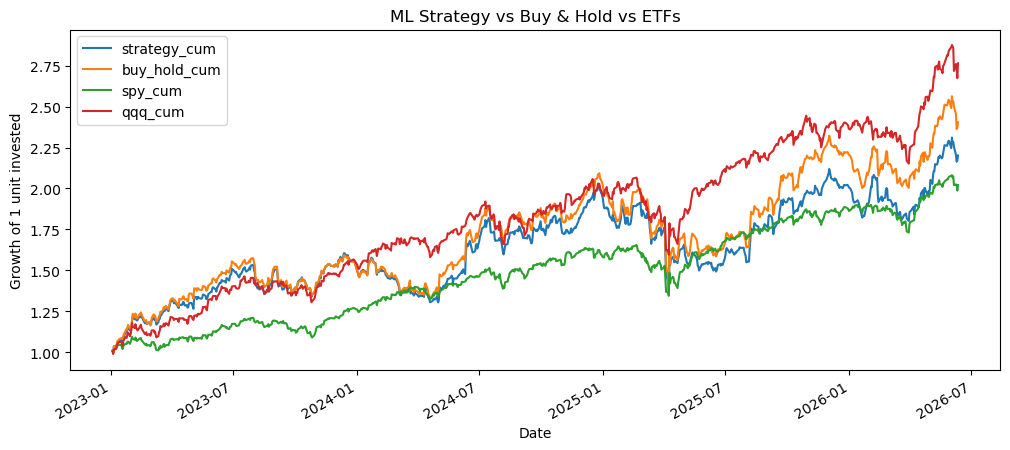

In [27]:
backtest[["strategy_cum", "buy_hold_cum", "spy_cum", "qqq_cum"]].plot(
    figsize=(12, 5),
    title="ML Strategy vs Buy & Hold vs ETFs"
)

plt.xlabel("Date")
plt.ylabel("Growth of 1 unit invested")
plt.show()

In [28]:
final_returns = backtest[["strategy_cum", "buy_hold_cum", "spy_cum", "qqq_cum"]].iloc[-1] - 1

final_returns


strategy_cum    1.201220
buy_hold_cum    1.403834
spy_cum         1.020861
qqq_cum         1.763801
Name: 2026-06-11 00:00:00, dtype: float64

In [29]:
final_returns_percent = final_returns * 100

final_returns_percent.sort_values(ascending=False)

qqq_cum         176.380102
buy_hold_cum    140.383384
strategy_cum    120.122024
spy_cum         102.086121
Name: 2026-06-11 00:00:00, dtype: float64

In [30]:
annual_volatility = backtest[[
    "strategy_returns",
    "buy_hold_returns",
    "spy_returns",
    "qqq_returns"
]].std() * (252 ** 0.5)

annual_volatility_percent = annual_volatility * 100

annual_volatility_percent.sort_values(ascending=False)

buy_hold_returns    25.449842
strategy_returns    24.800036
qqq_returns         19.982871
spy_returns         15.174821
dtype: float64

In [31]:
def sharpe_ratio(returns, risk_free_rate=0.02):
    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * (252 ** 0.5)
    return (annual_return - risk_free_rate) / annual_volatility


sharpe_results = pd.Series({
    "strategy": sharpe_ratio(backtest["strategy_returns"]),
    "buy_hold": sharpe_ratio(backtest["buy_hold_returns"]),
    "spy": sharpe_ratio(backtest["spy_returns"]),
    "qqq": sharpe_ratio(backtest["qqq_returns"])
})

sharpe_results

strategy    0.972731
buy_hold    1.055617
spy         1.299501
qqq         1.487417
dtype: float64

In [32]:
def max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns / running_max - 1
    return drawdown.min()


mdd_results = pd.Series({
    "strategy": max_drawdown(backtest["strategy_cum"]),
    "buy_hold": max_drawdown(backtest["buy_hold_cum"]),
    "spy": max_drawdown(backtest["spy_cum"]),
    "qqq": max_drawdown(backtest["qqq_cum"])
})

mdd_results_percent = mdd_results * 100

mdd_results_percent

strategy   -32.714330
buy_hold   -33.360514
spy        -18.755234
qqq        -22.768314
dtype: float64

In [33]:
tableau_recap = pd.DataFrame({
    "Rendement final (%)": [
        final_returns_percent["strategy_cum"],
        final_returns_percent["buy_hold_cum"],
        final_returns_percent["spy_cum"],
        final_returns_percent["qqq_cum"]
    ],
    "Volatilité annualisée (%)": [
        annual_volatility_percent["strategy_returns"],
        annual_volatility_percent["buy_hold_returns"],
        annual_volatility_percent["spy_returns"],
        annual_volatility_percent["qqq_returns"]
    ],
    "Sharpe ratio": [
        sharpe_results["strategy"],
        sharpe_results["buy_hold"],
        sharpe_results["spy"],
        sharpe_results["qqq"]
    ],
    "Max drawdown (%)": [
        mdd_results_percent["strategy"],
        mdd_results_percent["buy_hold"],
        mdd_results_percent["spy"],
        mdd_results_percent["qqq"]
    ]
}, index=[
    "ML Strategy",
    "Apple Buy & Hold",
    "SPY",
    "QQQ"
])

tableau_recap
tableau_recap_rounded = tableau_recap.round(2)

tableau_recap_rounded

,Rendement final (%),Volatilité annualisée (%),Sharpe ratio,Max drawdown (%)
ML Strategy,120.12,24.80,0.97,-32.71
Apple Buy & Hold,140.38,25.45,1.06,-33.36
SPY,102.09,15.17,1.30,-18.76
QQQ,176.38,19.98,1.49,-22.77


In [34]:
### Interprétation de la baseline Logistic Regression

#La stratégie basée sur la régression logistique génère une performance cumulée positive de 117.11% sur la période de test. Elle surperforme le benchmark large SPY en rendement final, mais reste inférieure à Apple Buy & Hold et à QQQ.

#En termes de risque, la stratégie ML présente une volatilité légèrement inférieure à Apple Buy & Hold, ainsi qu’un max drawdown légèrement moins important. Toutefois, son Sharpe ratio reste inférieur à celui des benchmarks passifs, en particulier QQQ et SPY.

#Cette première approche constitue donc une baseline ML rentable, mais elle ne permet pas encore d’améliorer significativement le couple rendement-risque. Cela justifie le passage à un modèle non linéaire, comme Random Forest, afin de mieux capter les relations complexes entre les variables de marché, le momentum, la volatilité et le rendement futur d’Apple.

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=20,
    random_state=42,
    class_weight="balanced"
)

In [36]:
rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_proba[:10].round(3)

array([0.522, 0.542, 0.457, 0.308, 0.511, 0.562, 0.537, 0.567, 0.55 ,
       0.58 ])

In [42]:
rf_pred = (rf_proba > 0.51).astype(int)

print(pd.Series(rf_pred).value_counts())

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

1    432
0    431
Name: count, dtype: int64
Random Forest Accuracy: 0.5052143684820394
[[198 194]
 [233 238]]
              precision    recall  f1-score   support

           0       0.46      0.51      0.48       392
           1       0.55      0.51      0.53       471

    accuracy                           0.51       863
   macro avg       0.51      0.51      0.50       863
weighted avg       0.51      0.51      0.51       863



In [43]:
def rf_allocation_rule(p):
    if p > 0.53:
        return 1.20
    elif p < 0.49:
        return 0.50
    else:
        return 1.00


rf_signal_weight = pd.Series(rf_proba, index=X_test.index).apply(rf_allocation_rule)

rf_signal_weight.value_counts()

1.0    402
0.5    231
1.2    230
Name: count, dtype: int64

In [44]:
rf_strategy_returns = rf_signal_weight.shift(1) * df.loc[X_test.index, "ret_aapl"]

rf_buy_hold_returns = df.loc[X_test.index, "ret_aapl"]

rf_spy_returns = df.loc[X_test.index, "ret_spy"]

rf_qqq_returns = df.loc[X_test.index, "ret_qqq"]

In [45]:
rf_backtest = pd.DataFrame({
    "rf_strategy_returns": rf_strategy_returns,
    "buy_hold_returns": rf_buy_hold_returns,
    "spy_returns": rf_spy_returns,
    "qqq_returns": rf_qqq_returns
}).dropna()

rf_backtest.head()

,rf_strategy_returns,buy_hold_returns,spy_returns,qqq_returns
2023-01-04,0.010314,0.010314,0.007720,0.004764
2023-01-05,-0.012726,-0.010605,-0.011413,-0.015654
2023-01-06,0.018397,0.036794,0.022932,0.027602
2023-01-09,0.002045,0.004089,-0.000567,0.006473
2023-01-10,0.004456,0.004456,0.007013,0.008464


In [46]:
rf_backtest["rf_strategy_cum"] = (1 + rf_backtest["rf_strategy_returns"]).cumprod()

rf_backtest["buy_hold_cum"] = (1 + rf_backtest["buy_hold_returns"]).cumprod()

rf_backtest["spy_cum"] = (1 + rf_backtest["spy_returns"]).cumprod()

rf_backtest["qqq_cum"] = (1 + rf_backtest["qqq_returns"]).cumprod()

rf_backtest[["rf_strategy_cum", "buy_hold_cum", "spy_cum", "qqq_cum"]].head()

,rf_strategy_cum,buy_hold_cum,spy_cum,qqq_cum
2023-01-04,1.010314,1.010314,1.007720,1.004764
2023-01-05,0.997457,0.999600,0.996219,0.989035
2023-01-06,1.015808,1.036380,1.019064,1.016334
2023-01-09,1.017884,1.040617,1.018486,1.022913
2023-01-10,1.022420,1.045255,1.025629,1.031571


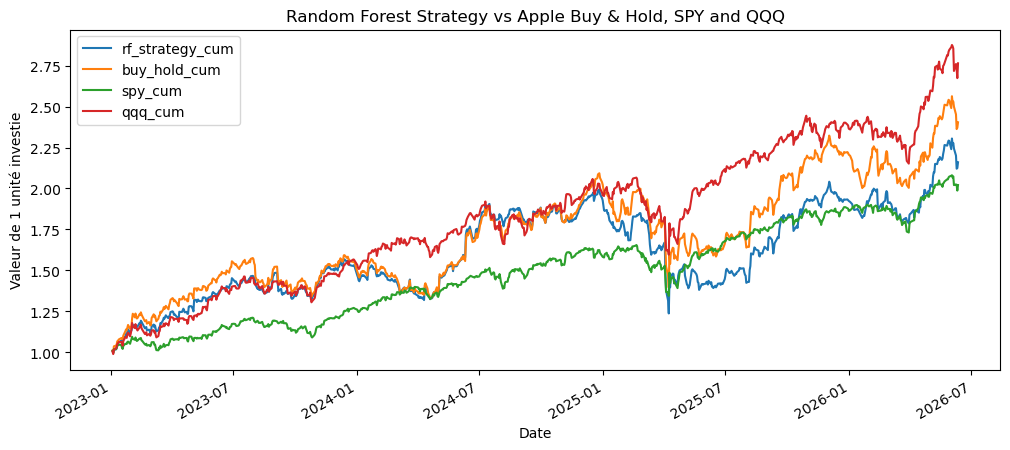

In [47]:
rf_backtest[["rf_strategy_cum", "buy_hold_cum", "spy_cum", "qqq_cum"]].plot(
    figsize=(12, 5),
    title="Random Forest Strategy vs Apple Buy & Hold, SPY and QQQ"
)

plt.xlabel("Date")
plt.ylabel("Valeur de 1 unité investie")
plt.show()

In [48]:
rf_final_returns = rf_backtest[[
    "rf_strategy_cum",
    "buy_hold_cum",
    "spy_cum",
    "qqq_cum"
]].iloc[-1] - 1

rf_final_returns_percent = rf_final_returns * 100

rf_final_returns_percent

rf_strategy_cum    115.977353
buy_hold_cum       140.383384
spy_cum            102.086121
qqq_cum            176.380102
Name: 2026-06-11 00:00:00, dtype: float64

In [49]:
rf_annual_volatility = rf_backtest[[
    "rf_strategy_returns",
    "buy_hold_returns",
    "spy_returns",
    "qqq_returns"
]].std() * (252 ** 0.5)

rf_annual_volatility_percent = rf_annual_volatility * 100

rf_annual_volatility_percent

rf_strategy_returns    24.779277
buy_hold_returns       25.449842
spy_returns            15.174821
qqq_returns            19.982871
dtype: float64

In [50]:
def sharpe_ratio(returns, risk_free_rate=0.02):
    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * (252 ** 0.5)
    return (annual_return - risk_free_rate) / annual_volatility


rf_sharpe_results = pd.Series({
    "Random Forest Strategy": sharpe_ratio(rf_backtest["rf_strategy_returns"]),
    "Apple Buy & Hold": sharpe_ratio(rf_backtest["buy_hold_returns"]),
    "SPY": sharpe_ratio(rf_backtest["spy_returns"]),
    "QQQ": sharpe_ratio(rf_backtest["qqq_returns"])
})

rf_sharpe_results

Random Forest Strategy    0.951057
Apple Buy & Hold          1.055617
SPY                       1.299501
QQQ                       1.487417
dtype: float64

In [51]:
def max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns / running_max - 1
    return drawdown.min()


rf_mdd_results = pd.Series({
    "Random Forest Strategy": max_drawdown(rf_backtest["rf_strategy_cum"]),
    "Apple Buy & Hold": max_drawdown(rf_backtest["buy_hold_cum"]),
    "SPY": max_drawdown(rf_backtest["spy_cum"]),
    "QQQ": max_drawdown(rf_backtest["qqq_cum"])
})

rf_mdd_results_percent = rf_mdd_results * 100

rf_mdd_results_percent

Random Forest Strategy   -37.935646
Apple Buy & Hold         -33.360514
SPY                      -18.755234
QQQ                      -22.768314
dtype: float64

In [52]:
rf_tableau_recap = pd.DataFrame({
    "Rendement final (%)": [
        rf_final_returns_percent["rf_strategy_cum"],
        rf_final_returns_percent["buy_hold_cum"],
        rf_final_returns_percent["spy_cum"],
        rf_final_returns_percent["qqq_cum"]
    ],
    "Volatilité annualisée (%)": [
        rf_annual_volatility_percent["rf_strategy_returns"],
        rf_annual_volatility_percent["buy_hold_returns"],
        rf_annual_volatility_percent["spy_returns"],
        rf_annual_volatility_percent["qqq_returns"]
    ],
    "Sharpe ratio": [
        rf_sharpe_results["Random Forest Strategy"],
        rf_sharpe_results["Apple Buy & Hold"],
        rf_sharpe_results["SPY"],
        rf_sharpe_results["QQQ"]
    ],
    "Max drawdown (%)": [
        rf_mdd_results_percent["Random Forest Strategy"],
        rf_mdd_results_percent["Apple Buy & Hold"],
        rf_mdd_results_percent["SPY"],
        rf_mdd_results_percent["QQQ"]
    ]
}, index=[
    "Random Forest Strategy",
    "Apple Buy & Hold",
    "SPY",
    "QQQ"
])

rf_tableau_recap_rounded = rf_tableau_recap.round(2)

rf_tableau_recap_rounded

,Rendement final (%),Volatilité annualisée (%),Sharpe ratio,Max drawdown (%)
Random Forest Strategy,115.98,24.78,0.95,-37.94
Apple Buy & Hold,140.38,25.45,1.06,-33.36
SPY,102.09,15.17,1.30,-18.76
QQQ,176.38,19.98,1.49,-22.77


In [53]:
tableau_final = pd.DataFrame({
    "Rendement final (%)": [
        final_returns_percent["strategy_cum"],
        rf_final_returns_percent["rf_strategy_cum"],
        rf_final_returns_percent["buy_hold_cum"],
        rf_final_returns_percent["spy_cum"],
        rf_final_returns_percent["qqq_cum"]
    ],
    "Volatilité annualisée (%)": [
        annual_volatility_percent["strategy_returns"],
        rf_annual_volatility_percent["rf_strategy_returns"],
        rf_annual_volatility_percent["buy_hold_returns"],
        rf_annual_volatility_percent["spy_returns"],
        rf_annual_volatility_percent["qqq_returns"]
    ],
    "Sharpe ratio": [
        sharpe_results["strategy"],
        rf_sharpe_results["Random Forest Strategy"],
        rf_sharpe_results["Apple Buy & Hold"],
        rf_sharpe_results["SPY"],
        rf_sharpe_results["QQQ"]
    ],
    "Max drawdown (%)": [
        mdd_results_percent["strategy"],
        rf_mdd_results_percent["Random Forest Strategy"],
        rf_mdd_results_percent["Apple Buy & Hold"],
        rf_mdd_results_percent["SPY"],
        rf_mdd_results_percent["QQQ"]
    ]
}, index=[
    "Logistic Regression Strategy",
    "Random Forest Strategy",
    "Apple Buy & Hold",
    "SPY",
    "QQQ"
])

tableau_final_rounded = tableau_final.round(2)

tableau_final_rounded

,Rendement final (%),Volatilité annualisée (%),Sharpe ratio,Max drawdown (%)
Logistic Regression Strategy,120.12,24.80,0.97,-32.71
Random Forest Strategy,115.98,24.78,0.95,-37.94
Apple Buy & Hold,140.38,25.45,1.06,-33.36
SPY,102.09,15.17,1.30,-18.76
QQQ,176.38,19.98,1.49,-22.77
